In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
ID2LABEL    = {i: name for i, name in enumerate(LABEL_NAMES)}
LABEL2ID    = {name: i for i, name in enumerate(LABEL_NAMES)}
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print("✅ All imports successful.")
print(f"   Device : {DEVICE}")
print(f"   PyTorch: {torch.__version__}")

✅ All imports successful.
   Device : cpu
   PyTorch: 2.12.0+cpu


In [2]:
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)
print("\nSample entry:")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Sample entry:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


Train size : 120,000
Test  size : 7,600

Class distribution (train):
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


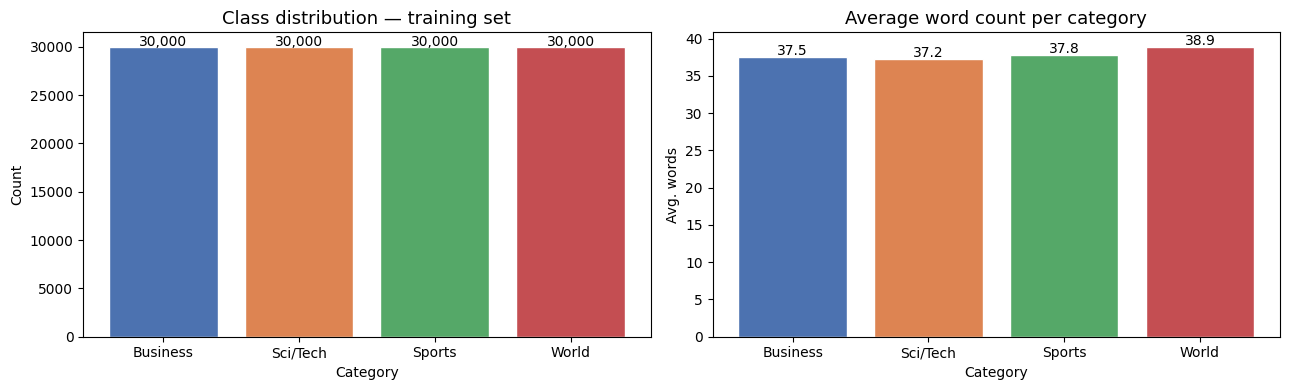

✅ Saved: eda_plots.png


In [3]:
train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

train_df["label_name"] = train_df["label"].map(ID2LABEL)
test_df["label_name"]  = test_df["label"].map(ID2LABEL)
train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))

print(f"Train size : {len(train_df):,}")
print(f"Test  size : {len(test_df):,}")
print("\nClass distribution (train):")
print(train_df["label_name"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = train_df["label_name"].value_counts()
axes[0].bar(counts.index, counts.values,
            color=["#4C72B0","#DD8452","#55A868","#C44E52"], edgecolor="white")
axes[0].set_title("Class distribution — training set", fontsize=13)
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=10)

avg_words = train_df.groupby("label_name")["word_count"].mean()
axes[1].bar(avg_words.index, avg_words.values,
            color=["#4C72B0","#DD8452","#55A868","#C44E52"], edgecolor="white")
axes[1].set_title("Average word count per category", fontsize=13)
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Avg. words")
for i, v in enumerate(avg_words.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_plots.png")

In [4]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
TRAIN_SIZE = 6000    # raise to 120000 for full training
TEST_SIZE  = 1200    # raise to 7600  for full evaluation

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH,
    )

small_train = dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
small_test  = dataset["test"].shuffle(seed=42).select(range(TEST_SIZE))

print("Tokenizing...")
train_tok = small_train.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok  = small_test.map(tokenize_fn,  batched=True, remove_columns=["text"])

train_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_tok.set_format( "torch", columns=["input_ids", "attention_mask", "label"])

print(f"✅ Train: {len(train_tok):,} samples")
print(f"✅ Test : {len(test_tok):,} samples")

Loading tokenizer: bert-base-uncased
Tokenizing...
✅ Train: 6,000 samples
✅ Test : 1,200 samples


In [5]:
print(f"Loading {MODEL_NAME}...")

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model loaded.")
print(f"   Total parameters    : {total:,}")
print(f"   Trainable parameters: {trainable:,}")

Loading bert-base-uncased...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2753.94it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

✅ Model loaded.
   Total parameters    : 109,485,316
   Trainable parameters: 109,485,316


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy"   : round(accuracy_score(labels, preds), 4),
        "f1_macro"   : round(f1_score(labels, preds, average="macro"),    4),
        "f1_weighted": round(f1_score(labels, preds, average="weighted"), 4),
    }

training_args = TrainingArguments(
    output_dir                  = "./bert_ag_news_checkpoints",
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = "epoch",
    save_strategy               = "no",        # ← no checkpoints saved
    load_best_model_at_end      = False,        # ← must be False with save_strategy="no"
    logging_steps               = 50,
    report_to                   = "none",
    fp16                        = torch.cuda.is_available(),
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = train_tok,
    eval_dataset      = test_tok,
    processing_class  = tokenizer,       
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)

print("Starting training...")
trainer.train()
print("✅ Training complete.")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.299937,0.292145,0.898300,0.897900,0.898000
2,0.240065,0.297084,0.911700,0.911300,0.911400
3,0.129773,0.299260,0.912500,0.912400,0.912600


✅ Training complete.


In [7]:
results = trainer.evaluate()

print("\n════════════════════════════")
print("      EVALUATION RESULTS")
print("══════════════════════════════")
for k, v in results.items():
    label = k.replace("eval_", "").replace("_", " ").capitalize()
    print(f"  {label:<20} {v:.4f}" if isinstance(v, float) else f"  {label:<20} {v}")
print("══════════════════════════════")

predictions = trainer.predict(test_tok)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("\nDetailed Classification Report:")
print("─" * 60)
print(classification_report(labels, preds, target_names=LABEL_NAMES))

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.129773,0.299260,3,0.912500,0.912400,0.912600



════════════════════════════
      EVALUATION RESULTS
══════════════════════════════
  Loss                 0.2993
  Accuracy             0.9125
  F1 macro             0.9124
  F1 weighted          0.9126
══════════════════════════════



Detailed Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       World       0.93      0.92      0.92       312
      Sports       0.98      0.97      0.97       297
    Business       0.88      0.87      0.88       289
    Sci/Tech       0.86      0.89      0.88       302

    accuracy                           0.91      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.91      0.91      0.91      1200



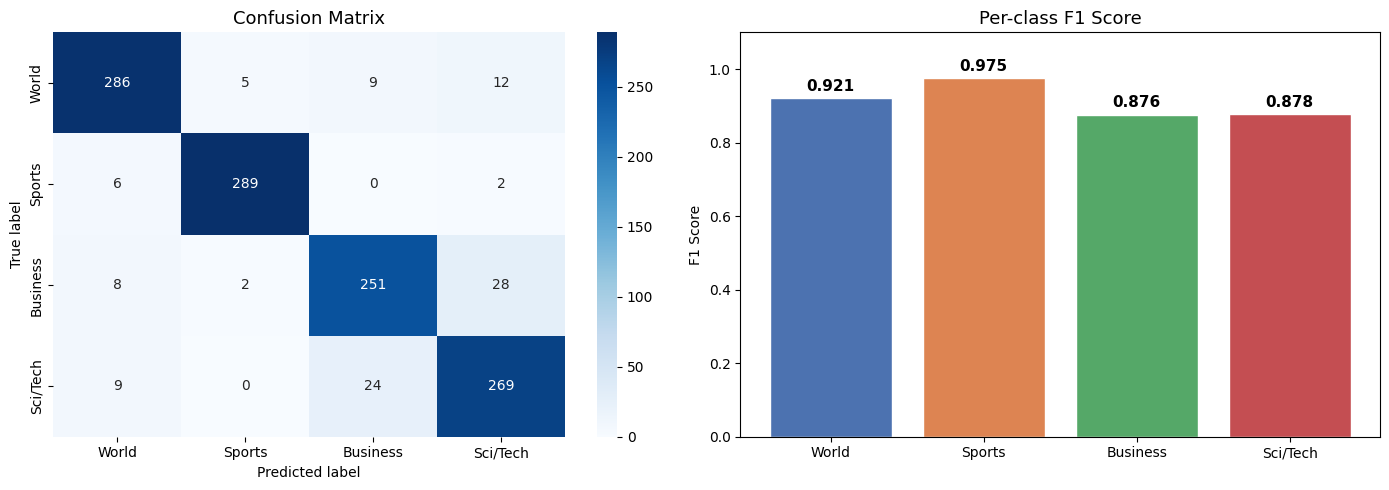

✅ Saved: evaluation_plots.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=13)
axes[0].set_ylabel("True label")
axes[0].set_xlabel("Predicted label")

# Per-class F1
f1_per_class = f1_score(labels, preds, average=None)
colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]
bars = axes[1].bar(LABEL_NAMES, f1_per_class, color=colors, edgecolor="white")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Per-class F1 Score", fontsize=13)
axes[1].set_ylabel("F1 Score")
for bar, val in zip(bars, f1_per_class):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}", ha="center", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: evaluation_plots.png")

In [9]:
SAVE_DIR = "./bert_ag_news_final"

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

import os
print(f"✅ Model saved to {SAVE_DIR}")
print(f"   Files: {os.listdir(SAVE_DIR)}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]

✅ Model saved to ./bert_ag_news_final
   Files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [10]:
import gradio as gr

clf_pipeline = pipeline(
    "text-classification",
    model     = "./bert_ag_news_final",
    tokenizer = "./bert_ag_news_final",
    device    = 0 if torch.cuda.is_available() else -1,
    top_k     = None,
)

def predict(text):
    if not text.strip():
        return {label: 0.0 for label in LABEL_NAMES}
    scores = clf_pipeline(text)[0]
    return {item["label"]: round(item["score"], 4) for item in scores}

examples = [
    "NASA launches new Mars rover mission scheduled for next year",
    "Federal Reserve raises interest rates amid inflation concerns",
    "Manchester United wins Premier League title in dramatic comeback",
    "UN Security Council meets to discuss tensions in Eastern Europe",
    "Apple unveils new M3 chip with major performance improvements",
    "Olympic gold medalist breaks world record in 100m sprint",
]

demo = gr.Interface(
    fn          = predict,
    inputs      = gr.Textbox(lines=3, placeholder="Enter a news headline...", label="News Text"),
    outputs     = gr.Label(num_top_classes=4, label="Topic Probabilities"),
    title       = "📰 AG News Topic Classifier — BERT",
    description = "Fine-tuned bert-base-uncased | Categories: World · Sports · Business · Sci/Tech",
    examples    = examples,
    theme       = gr.themes.Soft(),
)

demo.launch(share=True)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2858.90it/s]


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://14d32239fe0b6492eb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
